In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [3]:
cali = fetch_california_housing()
df = pd.DataFrame(cali.data, columns=cali.feature_names)
df['Target'] = cali.target
print(df.shape)
df

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [4]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1:].values
print(X.shape, y.shape)

(20640, 8) (20640, 1)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(16512, 8) (4128, 8) (16512, 1) (4128, 1)


In [6]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0)
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(12384, 8) (4128, 8) (4128, 8) (12384, 1) (4128, 1) (4128, 1)


In [7]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_sc = scaler.transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

In [8]:
X_train_sc_tensor = torch.from_numpy(X_train_sc).float()
X_val_sc_tensor = torch.from_numpy(X_val_sc).float()
X_test_sc_tensor = torch.from_numpy(X_test_sc).float()
y_train_tensor = torch.from_numpy(y_train).float()
y_val_tensor = torch.from_numpy(y_val).float()
y_test_tensor = torch.from_numpy(y_test).float()
print(X_train_sc_tensor.shape, X_val_sc_tensor.shape, X_test_sc_tensor.shape, y_train_tensor.shape, y_val_tensor.shape, y_test_tensor.shape)

torch.Size([12384, 8]) torch.Size([4128, 8]) torch.Size([4128, 8]) torch.Size([12384, 1]) torch.Size([4128, 1]) torch.Size([4128, 1])


In [9]:
model = nn.Sequential(
    nn.Linear(X_train_sc_tensor.shape[-1], 7),
    nn.LeakyReLU(),
    nn.Linear(7, 5),
    nn.LeakyReLU(),
    nn.Linear(5, 3),
    nn.LeakyReLU(),
    nn.Linear(3, y_train_tensor.shape[-1]),
)
model = model.to(device)
print(model)

Sequential(
  (0): Linear(in_features=8, out_features=7, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=7, out_features=5, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=5, out_features=3, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=3, out_features=1, bias=True)
)


In [10]:
lowest_loss = np.inf
best_model = None
early_stop = 1000
lowest_epoch = np.inf

In [11]:
n_epochs = 30000
batch_size = 2048
learning_rate = 1e-4
print_interval = 1000

In [12]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [13]:
train_history, valid_history = [], []

for i in range(n_epochs):
    indices = torch.randperm(X_train_sc_tensor.shape[0])
    X_ = torch.index_select(X_train_sc_tensor, dim=0, index=indices).to(device)
    y_ = torch.index_select(y_train_tensor, dim=0, index=indices).to(device)
    
    X_ = X_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    train_loss, valid_loss = 0, 0
    y_hat = []

    for X_i, y_i in zip(X_, y_):
        y_hat_i = model(X_i)
        loss = F.mse_loss(y_hat_i, y_i)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += float(loss.detach())
    
    train_loss = train_loss / len(X_)

    with torch.no_grad():
        X_ = X_val_sc_tensor.to(device).split(batch_size, dim=0)
        y_ = y_val_tensor.to(device).split(batch_size, dim=0)

        valid_loss = 0

        for X_i, y_i in zip(X_, y_):
            y_hat_i = model(X_i)
            loss = F.mse_loss(y_hat_i, y_i)

            valid_loss += float(loss.detach())

            y_hat += [y_hat_i]
        
        valid_loss = valid_loss / len(X_)
    
    train_history += [train_loss]
    valid_history += [valid_loss]

    if (i + 1) % print_interval == 0:
        print(f'Epoch {i + 1}: train loss={train_loss:.4f}, valid loss={valid_loss:.4f}, lowest loss={lowest_loss:.4f}')

    if valid_loss <= lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = i

        best_model = deepcopy(model.state_dict())
    else:
        if early_stop > 0 and lowest_epoch + early_stop < i + 1:
            print(f'There is no improvement during last {early_stop} epochs.')
            break
    
print(f'The best validation loss from epoch {lowest_epoch + 1}: {lowest_loss:.4f}')

model.load_state_dict(best_model)

Epoch 1000: train loss=0.4680, valid loss=0.4861, lowest loss=0.4865
Epoch 2000: train loss=0.3659, valid loss=0.3745, lowest loss=0.3745
Epoch 3000: train loss=0.3813, valid loss=0.3514, lowest loss=0.3505
Epoch 4000: train loss=0.3430, valid loss=0.3447, lowest loss=0.3430
Epoch 5000: train loss=0.3369, valid loss=0.3419, lowest loss=0.3407
Epoch 6000: train loss=0.3271, valid loss=0.3424, lowest loss=0.3404
There is no improvement during last 1000 epochs.
The best validation loss from epoch 5087: 0.3404


<All keys matched successfully>

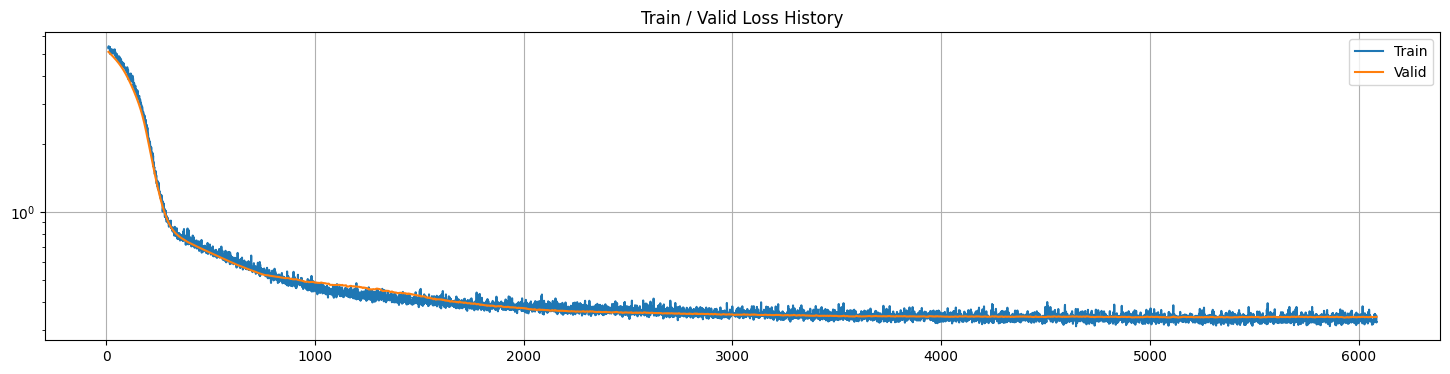

In [14]:
plot_from = 10

fig, ax = plt.subplots(1, 1, figsize=(18, 4))
plt.title('Train / Valid Loss History')
ax.plot(range(plot_from, len(train_history)), train_history[plot_from:],
         range(plot_from, len(valid_history)), valid_history[plot_from:])
plt.grid(True)
plt.yscale('log')
plt.legend(['Train', 'Valid'])
plt.show()

In [15]:
test_loss = 0
y_hat = []

with torch.no_grad():
    X_ = X_test_sc_tensor.to(device).split(batch_size, dim=0)
    y_ = y_test_tensor.to(device).split(batch_size, dim=0)

    for X_i, y_i in zip(X_, y_):
        y_hat_i = model(X_i)
        loss = F.mse_loss(y_hat_i, y_i)

        test_loss += float(loss.detach())

        y_hat += [y_hat_i]
    
    test_loss = test_loss / len(X_)

y_hat = torch.concat(y_hat, dim=0)

In [16]:
sorted_history = sorted(zip(train_history, valid_history), key=lambda x: x[1])

print(f'Train loss: {sorted_history[0][0]:.4f}')
print(f'Valid loss: {sorted_history[0][1]:.4f}')
print(f'Test loss: {test_loss:.4f}')

Train loss: 0.3433
Valid loss: 0.3404
Test loss: 0.3091


In [17]:
del model
torch.cuda.empty_cache()